In [ ]:
import pandas as pd


In [6]:
!pip install umap-learn



In [ ]:
#Leemos el dataframe
df = pd.read_csv("genres_v2.csv")

/var/folders/mt/jht7x_zx7q74g1bmh0zcxgt40000gn/T/ipykernel_54640/1138216768.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("genres_v2.csv")


In [ ]:
#visualizamos las primeras filas
df.head()

In [ ]:
#como para este ejercicio solo nos interesan las variables numéricas miramos cuales lo son
df.dtypes

danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                 object
id                   object
uri                  object
track_href           object
analysis_url         object
duration_ms           int64
time_signature        int64
genre                object
song_name            object
Unnamed: 0          float64
title                object
dtype: object

In [ ]:
#seleccionamos solo las variables numericas que son caracteristicas interesantes de la musica
df = df.select_dtypes('float64')

In [ ]:
#nos quitamos los valores NaN

df = df.dropna()

In [ ]:
#normalizamos todos los datos numericos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df = scaler.fit_transform(df)
df

array([[ 1.40177505,  0.676664  , -0.31927979, ...,  1.32372293,
        -0.98078572, -1.73225382],
       [ 1.38107139, -1.50644647, -1.26333168, ...,  0.2567618 ,
        -1.10806566, -1.73208859],
       [ 0.87038117,  0.91827307, -0.27132461, ...,  2.24223729,
        -1.17295348, -1.73192337],
       ...,
       [-1.6692675 , -0.43646347,  0.96885925, ..., -0.79164348,
         0.74302884,  1.73705516],
       [-0.86872607,  0.42642605,  0.38254596, ...,  0.89693848,
         0.42991633,  1.73722039],
       [-0.50986267,  0.63351953,  0.00275497, ..., -0.74525386,
         0.75019593,  1.73738562]])

In [ ]:
#aplicamos el umap para agrupar las caracteristicas
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,   # tamaño del vecindario
    min_dist=0.1,     # compresión de clusters
    n_components=2,   # para visualizar en 2D
    random_state=42
)

X_umap = reducer.fit_transform(df)

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


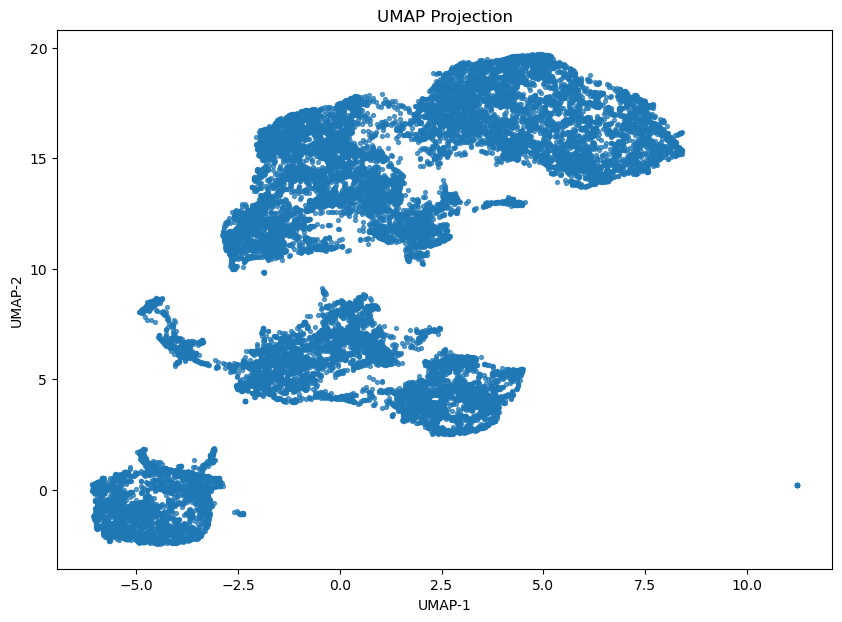

In [ ]:
#dibujamos el umap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=8, alpha=0.7)
plt.title("UMAP Projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

SSE: 118496.1015625
Silhouette Score: 0.5619447231292725


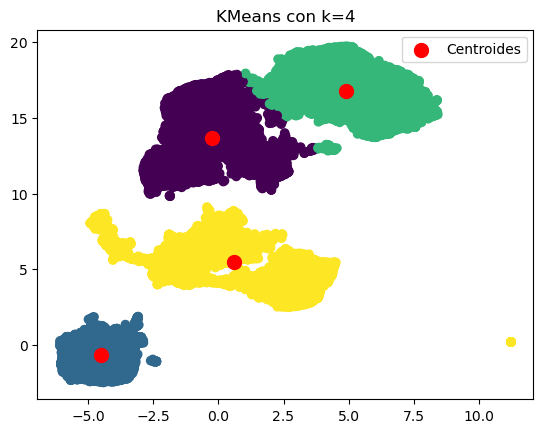

In [ ]:
#en el umap podemos apreciar 4 grupos asi que le pasamos k = 4 al KMeans 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_umap)

SSE = kmeans.inertia_
print("SSE:", SSE)

# 4. Silhouette Score
silhouette = silhouette_score(X_umap, labels)
print("Silhouette Score:", silhouette)

# 5. Plot clusters
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=100, c='red', marker='o', label='Centroides')
plt.title(f"KMeans con k={k}")
plt.legend()
plt.show()


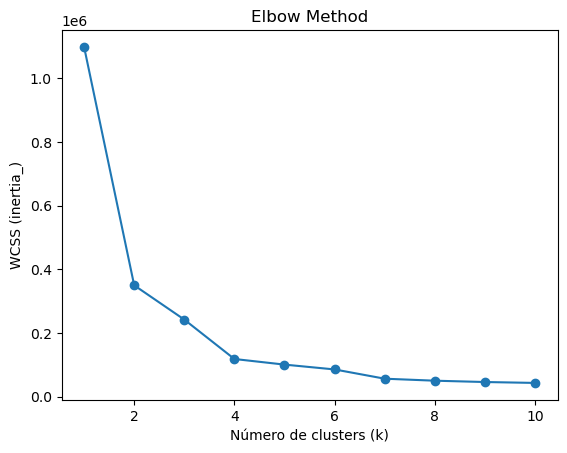

In [ ]:
#Comprobamos que efectivamente se generan 4 clusters mediante el elbow Method
wcss = []


for i in range(1, 11):
    model = KMeans(n_clusters=i)
    model.fit(X_umap)
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_umap)
    wcss.append(kmeans.inertia_)



plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS (inertia_)")
plt.show()

In [53]:
silhouette = silhouette_score(X_umap,labels)
print("Silhoutte Score = {:.3f}".format(silhouette))

Silhoutte Score = 0.562
